# **GPA Change Prediction**

outlook

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders as ce
import scipy.stats as stats

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import metrics

import preprocessing as pr
import utils

print("Importations Successful.")

Importations Successful.


In [2]:
# versions of the used third-party packages
from sklearn import __version__ as sklearn_version
from numpy import __version__ as np_version
from pandas import __version__ as pd_version
from seaborn import __version__ as sns_version
from matplotlib import __version__ as plt_version

print(f"Scikit-learn's Version: {sklearn_version}")
print(f"NumPy's Version: {np_version}")
print(f"Pandas's Version: {pd_version}")
print(f"Seaborn's Version: {sns_version}")
print(f"Matploblib's Version: {plt_version}")

Scikit-learn's Version: 1.9.0
NumPy's Version: 2.4.2
Pandas's Version: 3.0.0
Seaborn's Version: 0.13.2
Matploblib's Version: 3.10.8


In [3]:
sns.set_theme(
    context="notebook",
    style="whitegrid"
)

# Introduction:

We did a regression project to identify the GPA difference of each student using features in the dataset. Now in this project we have a plan to make that regression project to a classification project and instead of predicting the exact GPA difference we want to predict the GPA difference between these categories: ["low", "medium", "high"]

We hope to get great results using less features and the primary goal of this project is that we want to exercise a classification project.

- **Regression Problem Path:** core_ml/regression/impact_of_ai_on_students

# Problem Definition:

predict that based-on the data features what would be the student's GPA difference.

In [4]:
df = pd.read_csv("../data/ai_student_impact_dataset (1).csv")
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [5]:
# fixing datatypes for categorical variables
df['Major_Category'] = df['Major_Category'].str.lower().astype("category")
df['Year_of_Study'] = df['Year_of_Study'].str.lower().astype("category")
df['Primary_Use_Case'] = df['Primary_Use_Case'].str.lower().astype("category")
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].str.lower().astype("category")
df['Institutional_Policy'] = df['Institutional_Policy'].str.lower().astype("category")
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].str.lower().astype("category")

In [6]:
# creating the target variable
df['GPA_Difference'] = abs(df['Post_Semester_GPA'] - df['Pre_Semester_GPA'])
df['GPA_Difference'] = pd.cut(
    df['GPA_Difference'],
    bins=[-0.01, 0.3, 0.6, np.inf],
    labels=["low", "medium", "high"]
)

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Difference
0,100001,humanities,senior,2.418,23.31,copywriting/drafting,beginner,1,True,8.13,5,allowed_with_citation,6,2.393,86.44,high,low
1,100002,medical,junior,3.821,1.12,ideation,advanced,5,False,16.65,3,allowed_with_citation,9,3.696,69.39,low,low
2,100003,business,freshman,3.398,21.26,summarizing_reading,beginner,2,False,10.35,5,strict_ban,9,3.499,73.93,medium,low
3,100004,business,senior,3.789,1.82,copywriting/drafting,intermediate,4,False,15.23,2,allowed_with_citation,2,4.000,63.58,medium,low
4,100005,stem,sophomore,3.635,9.29,debugging/troubleshooting,advanced,4,False,12.55,4,allowed_with_citation,4,3.798,100.00,medium,low


In [7]:
pr.category_percentage(df['GPA_Difference'])

,GPA_Difference,percent
0,low,% 69.71
1,medium,% 28.49
2,high,% 1.80


we have a task of imbalaced classification.

In [8]:
# encoding
df['Paid_Subscription'] = df['Paid_Subscription'].astype("category").cat.codes
df['GPA_Difference'] = df['GPA_Difference'].cat.codes
feature_names = [feature for feature in df.columns if feature not in ["Student_ID", "GPA_Difference"]]

X = df[feature_names]
y = df['GPA_Difference']

# encoding
oh_encoding_cols = ["Major_Category", "Primary_Use_Case", "Institutional_Policy"]
ordinal_cols = ["Year_of_Study", "Prompt_Engineering_Skill", "Burnout_Risk_Level"]
mapping = [
    {
        "col": "Year_of_Study",
        "mapping": {
            "freshman": 0,
            "sophomore": 1,
            "junior": 2,
            "senior": 3,
            "graduate": 4
		}
	},
    {
        "col": "Prompt_Engineering_Skill",
        "mapping":{
            "beginner": 0,
            "intermediate": 1,
            "advanced": 2
		}
	},
    {
        "col": "Burnout_Risk_Level",
        "mapping": {
            "low": 0,
            "medium": 1,
            "high": 2
		}
	}
]

encoder = Pipeline(
    steps=[
        ("one_hot", ce.OneHotEncoder(cols=oh_encoding_cols, use_cat_names=True)),
        ("ordinal_1", ce.OrdinalEncoder(mapping=mapping, cols=ordinal_cols))
	]
)
features_encoded = pd.DataFrame(
    data=encoder.fit_transform(X),
    columns=encoder.get_feature_names_out()
)

# droping the non-informative column in the one-hot encoded features (one is non-informative in each)
non_informative_features = [
    "Major_Category_arts",
    "Primary_Use_Case_direct_answer_generation",
    "Institutional_Policy_actively_encouraged"
] # remove non-informative features that created during one-hot encoding
informative_features = [feature for feature in features_encoded.columns if feature not in non_informative_features]
features_encoded = features_encoded[informative_features]

features_encoded.head(10)

,Major_Category_humanities,Major_Category_medical,Major_Category_business,Major_Category_stem,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case_copywriting/drafting,Primary_Use_Case_ideation,Primary_Use_Case_summarizing_reading,...,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy_allowed_with_citation,Institutional_Policy_strict_ban,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,1,0,0,0,3,2.418,23.31,1,0,0,...,1,1,8.13,5,1,0,6,2.393,86.44,2
1,0,1,0,0,2,3.821,1.12,0,1,0,...,5,0,16.65,3,1,0,9,3.696,69.39,0
2,0,0,1,0,0,3.398,21.26,0,0,1,...,2,0,10.35,5,0,1,9,3.499,73.93,1
3,0,0,1,0,3,3.789,1.82,1,0,0,...,4,0,15.23,2,1,0,2,4.000,63.58,1
4,0,0,0,1,1,3.635,9.29,0,0,0,...,4,0,12.55,4,1,0,4,3.798,100.00,1
5,0,0,0,1,2,3.449,6.50,0,0,0,...,1,0,14.19,4,1,0,5,3.666,65.92,2
6,0,0,0,1,0,3.622,31.41,0,0,1,...,5,1,13.11,8,1,0,7,4.000,67.97,1
7,0,0,0,0,2,2.746,5.33,1,0,0,...,3,0,18.45,2,0,0,1,2.965,85.09,1
8,0,0,1,0,1,3.420,2.00,0,0,0,...,2,1,2.87,1,0,1,5,3.396,55.71,1
9,0,0,1,0,1,3.046,19.99,0,0,0,...,2,1,12.49,3,0,1,8,2.978,87.18,2


In [9]:
X = features_encoded.to_numpy()
y = df['GPA_Difference'].to_numpy()

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # to make it reproducable
)

# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# model training
logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

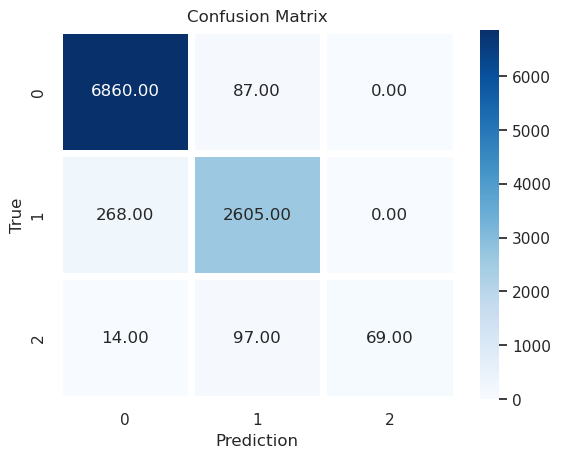

In [55]:
y_pred = logreg.predict(X_test_scaled)
utils.plot_confusion_matrix(y_test, y_pred)

In [56]:
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      6947
           1       0.93      0.91      0.92      2873
           2       1.00      0.38      0.55       180

    accuracy                           0.95     10000
   macro avg       0.96      0.76      0.82     10000
weighted avg       0.95      0.95      0.95     10000



In [58]:
param_grid = {
    "C": [50, 80, 100, 120],
    "l1_ratio": [0, 0.3, 0.5, 0.8, 1]
}
scorings = [
    metrics.make_scorer(metrics.recall_score, average="macro"),
    metrics.make_scorer(metrics.balanced_accuracy_score, )
]

grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
	scoring=metrics.make_scorer(metrics.balanced_accuracy_score, ),
	n_jobs=-1,
	cv=5,
	verbose=1
)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/erfan_taherirani/miniconda3/envs/data-processing/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [50, 80, ...], 'l1_ratio': [0, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(b...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to 

In [67]:
logreg = LogisticRegression(**grid.best_params_)
logreg.fit(X_train_scaled, y_train)

print(metrics.classification_report(y_test, logreg.predict(X_test)))

              precision    recall  f1-score   support

           0       0.73      0.94      0.83      6947
           1       0.54      0.20      0.29      2873
           2       1.00      0.01      0.01       180

    accuracy                           0.71     10000
   macro avg       0.76      0.38      0.38     10000
weighted avg       0.68      0.71      0.66     10000

